In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)


# 1. Data Loading

## 1.1 Fetch stock data

In [2]:
from src.data import TICKER_DEFAULT, fetch_stock

stocks = {TICKER_DEFAULT: fetch_stock(TICKER_DEFAULT)}
print(TICKER_DEFAULT, stocks[TICKER_DEFAULT].shape,
      "from", stocks[TICKER_DEFAULT].index.min().date(),
      "to",   stocks[TICKER_DEFAULT].index.max().date())

MSFT (3616, 6) from 2012-01-03 to 2026-05-20


In [3]:
from src.data import fetch_macro

macro = fetch_macro()
print("Macro shape:", macro.shape)
print(macro.tail())

Macro shape: (3620, 6)
                  VIX          SPX        DXY    TNX         OIL         GOLD
Date                                                                         
2026-05-14  17.260000  7501.240234  98.879997  4.461  101.169998  4678.100098
2026-05-15  18.430000  7408.500000  99.269997  4.595  105.419998  4555.799805
2026-05-18  17.820000  7403.049805  98.970001  4.623  108.660004  4552.500000
2026-05-19  18.059999  7353.609863  99.300003  4.667  107.769997  4506.299805
2026-05-20  17.900000  7392.310059  99.469002  4.657  102.559998  4473.600098


In [4]:
from src.data import build_dataset

dataset = build_dataset(TICKER_DEFAULT, stocks, macro)
print("Dataset shape:", dataset.shape)
print("Columns:", list(dataset.columns))
dataset.head()

Dataset shape: (3616, 12)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'VIX', 'SPX', 'DXY', 'TNX', 'OIL', 'GOLD']


,Open,High,Low,Close,Volume,Ticker,VIX,SPX,DXY,TNX,OIL,GOLD
Date,,,,,,,,,,,,
2012-01-03,20.745779,21.066147,20.620757,20.917685,64731500,MSFT,22.969999,1277.060059,79.610001,1.960,102.959999,1599.699951
2012-01-04,20.956764,21.464664,20.925509,21.409967,80516100,MSFT,22.219999,1277.300049,80.089996,1.995,103.220001,1611.900024
2012-01-05,21.394333,21.667819,21.324010,21.628750,56081400,MSFT,21.480000,1281.060059,80.940002,1.993,101.809998,1619.400024
2012-01-06,21.511545,22.027259,21.511545,21.964748,99455500,MSFT,20.629999,1277.810059,81.239998,1.961,101.559998,1616.099976
2012-01-09,21.917869,21.956939,21.660012,21.675640,59706800,MSFT,21.070000,1280.699951,81.050003,1.960,101.309998,1607.500000


# 2. EDA & Pre-processing

## 2.1 Dataset Overview

In [5]:
df = dataset.copy()
df["LogVolume"] = np.log1p(df["Volume"])  # heavy right-tail

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nDate range:", df.index.min().date(), "to", df.index.max().date())


Shape: (3616, 13)

Dtypes:
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Ticker           str
VIX          float64
SPX          float64
DXY          float64
TNX          float64
OIL          float64
GOLD         float64
LogVolume    float64
dtype: object

Date range: 2012-01-03 to 2026-05-20


## 2.2 Missing Values

In [6]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing_count, "pct(%)": missing_pct})
print(missing_table)

df = df.dropna()
print("After dropna:", df.shape)

           missing  pct(%)
Open             0     0.0
High             0     0.0
Low              0     0.0
Close            0     0.0
Volume           0     0.0
Ticker           0     0.0
VIX              0     0.0
SPX              0     0.0
DXY              0     0.0
TNX              0     0.0
OIL              0     0.0
GOLD             0     0.0
LogVolume        0     0.0
After dropna: (3616, 13)


## 2.3 Duplicates

In [7]:
print("Duplicated rows:",  df.duplicated().sum())
print("Duplicated index:", df.index.duplicated().sum())

df = df[~df.index.duplicated(keep="first")]

Duplicated rows: 0
Duplicated index: 0


## 2.4 Outliers (IQR rule, k=1.5)

Close       :    0 outliers (0.0%)  bounds=[-325.40, 650.91]
Volume      :  180 outliers (5.0%)  bounds=[-1869275.00, 60003125.00]
LogVolume   :   61 outliers (1.7%)  bounds=[16.06, 18.24]


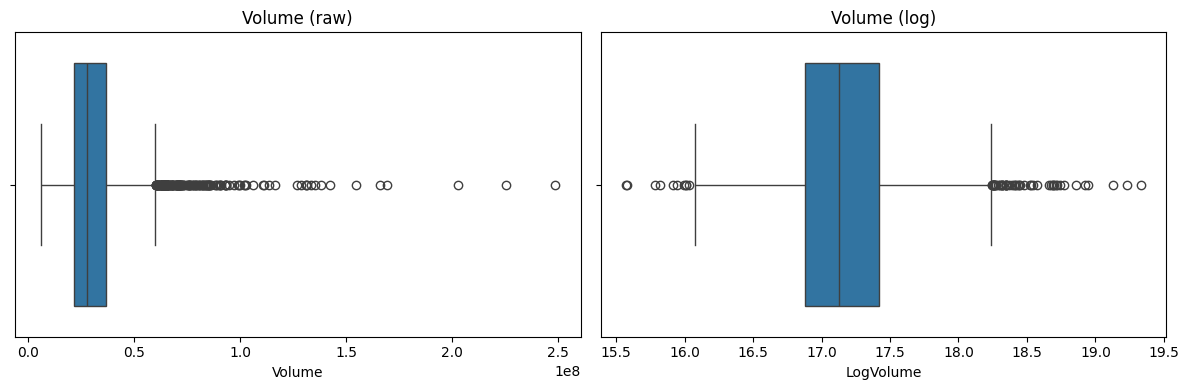

In [8]:
def iqr_outliers(series: pd.Series, k: float = 1.5):
    """Outlier if outside [Q1 - k*IQR, Q3 + k*IQR]."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - k * IQR, Q3 + k * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in ["Close", "Volume", "LogVolume"]:
    mask, lo, hi = iqr_outliers(df[col])
    print(f"{col:12s}: {mask.sum():4d} outliers ({mask.mean()*100:.1f}%)  "
          f"bounds=[{lo:.2f}, {hi:.2f}]")

# boxplot before/after log on Volume
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Volume"],     ax=axes[0]); axes[0].set_title("Volume (raw)")
sns.boxplot(x=df["LogVolume"],  ax=axes[1]); axes[1].set_title("Volume (log)")
plt.tight_layout()
plt.show()

## 2.5 Uniqueness check

In [9]:
print(df.nunique().sort_values())

Ticker          1
VIX          1581
DXY          1835
TNX          2135
OIL          2875
GOLD         2985
Close        3478
Volume       3603
LogVolume    3603
SPX          3603
High         3609
Open         3612
Low          3614
dtype: int64


## 2.6 Descriptive Statistics

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,50%,75%,max
Open,3616.0,174.28,107.23,149.59,20.75,40.70,107.23,284.69,5.520200e+02
High,3616.0,175.90,107.90,150.88,21.07,41.03,107.90,286.53,5.522400e+02
Low,3616.0,172.57,106.75,148.17,20.62,40.35,106.75,281.81,5.385300e+02
Close,3616.0,174.31,107.39,149.58,20.92,40.72,107.39,284.80,5.398300e+02
Volume,3616.0,31589333.30,27478000.00,16581348.88,5807626.00,21332875.00,27478000.00,36800975.00,2.484285e+08
VIX,3616.0,17.76,16.16,6.52,9.14,13.50,16.16,20.09,8.269000e+01
SPX,3616.0,3293.47,2832.95,1533.67,1277.06,2059.80,2832.95,4321.38,7.501240e+03
DXY,3616.0,94.82,96.45,8.11,78.27,90.94,96.45,99.88,1.141100e+02
TNX,3616.0,2.60,2.39,1.06,0.50,1.80,2.39,3.44,4.990000e+00
OIL,3616.0,69.62,68.15,20.97,-37.63,52.78,68.15,86.61,1.237000e+02


## 2.7 Univariate, Bivariate, Multivariate analysis

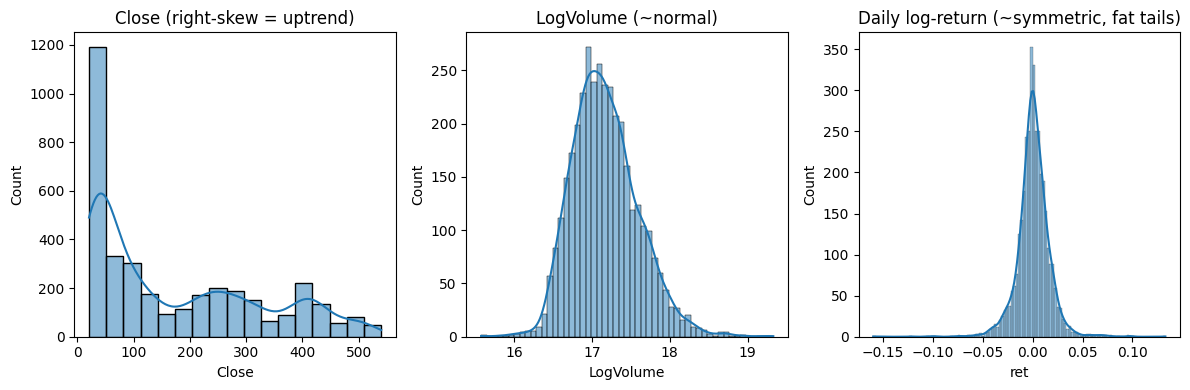

In [11]:
# temporary log-return for analysis (re-defined properly in features.py)
df["ret"] = np.log(df["Close"] / df["Close"].shift(1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(df["Close"],     kde=True, ax=axes[0]); axes[0].set_title("Close (right-skew = uptrend)")
sns.histplot(df["LogVolume"], kde=True, ax=axes[1]); axes[1].set_title("LogVolume (~normal)")
sns.histplot(df["ret"].dropna(), kde=True, ax=axes[2]); axes[2].set_title("Daily log-return (~symmetric, fat tails)")
plt.tight_layout(); plt.show()

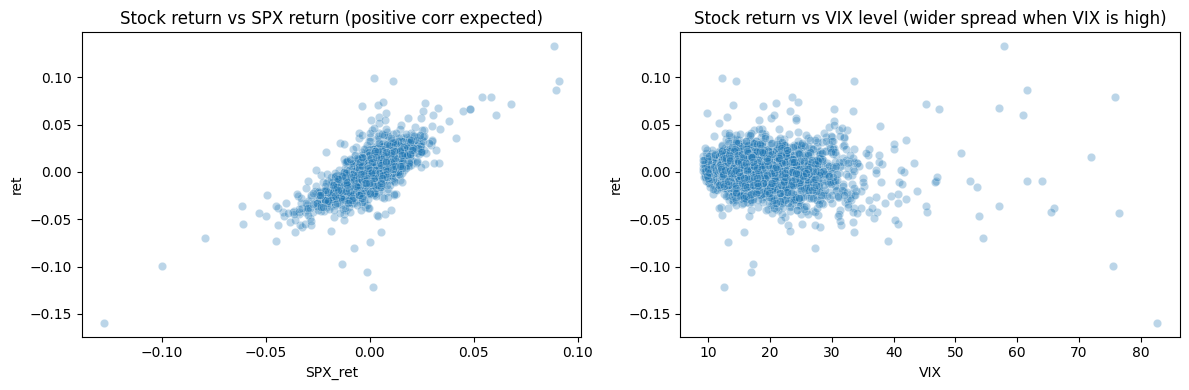

In [12]:
df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df["SPX_ret"], y=df["ret"], ax=axes[0], alpha=0.3)
axes[0].set_title("Stock return vs SPX return (positive corr expected)")
sns.scatterplot(x=df["VIX"], y=df["ret"], ax=axes[1], alpha=0.3)
axes[1].set_title("Stock return vs VIX level (wider spread when VIX is high)")
plt.tight_layout(); plt.show()


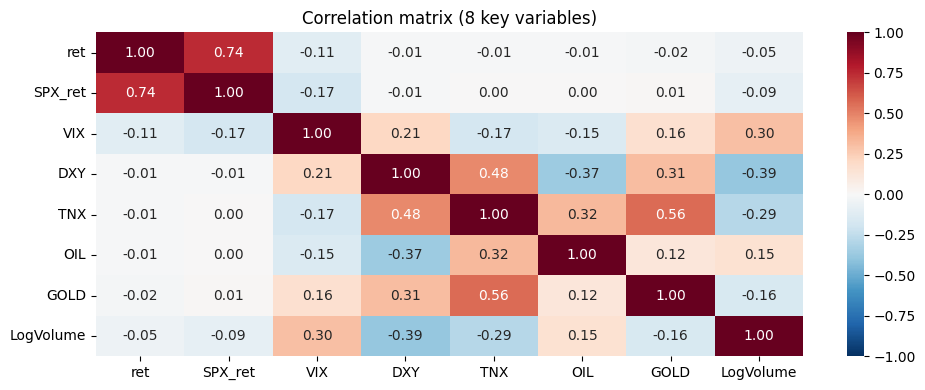

In [13]:
corr_cols = ["ret", "SPX_ret", "VIX", "DXY", "TNX", "OIL", "GOLD", "LogVolume"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (8 key variables)")
plt.tight_layout(); plt.show()

## 2.8 Conclusion & Strategy

**Findings**:
1. Data is clean: no missing after merge, no duplicates.
2. Close shows uptrend (non-stationary). We predict returns, not prices.
3. Volume is right-skewed. Use log(1+Volume) everywhere.
4. Daily returns are roughly symmetric but have fat tails. Winsorize the training target at ±2σ.
5. SPX/VIX correlate strongly with stock return. Keep all 6 macros as features.

**Decisions for next phase**:
- Target = 5-day forward log-return (one trading week).
- Features: technical (lag returns, MA ratios, RSI, MACD, Bollinger, microstructure), macro (VIX/SPX/DXY/TNX/OIL/GOLD as lagged returns), calendar (day-of-week, month, month-end).
- Split 70/15/15 sequential, no shuffle. 5-day embargo at each boundary.
- Models: NaiveZero and AlwaysLong baselines, LinearRegression, RandomForest.
- Tune RF on the held-out val set.
- Evaluate by IC, DirAcc, and walk-forward Sharpe.


# 3. Feature Engineering

In [14]:
from src.features import build_training_set

feat_df = build_training_set(TICKER_DEFAULT, stocks, macro)
print("Feature df shape:", feat_df.shape)
print("Columns:", list(feat_df.columns))

Feature df shape: (3548, 57)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'VIX', 'SPX', 'DXY', 'TNX', 'OIL', 'GOLD', 'LogVolume', 'ret', 'ret_lag1', 'ret_lag5', 'ret_lag10', 'ret_ma5', 'ret_std5', 'ret_ma10', 'ret_std10', 'ret_ma20', 'ret_std20', 'price_ma20_ratio', 'price_ma50_ratio', 'gap', 'intraday_range', 'close_loc', 'bb_pos', 'rsi14', 'macd', 'macd_hist', 'vol_z20', 'VIX_ret1', 'VIX_ret5', 'VIX_lag1', 'SPX_ret1', 'SPX_ret5', 'SPX_lag1', 'DXY_ret1', 'DXY_ret5', 'DXY_lag1', 'TNX_ret1', 'TNX_ret5', 'TNX_lag1', 'OIL_ret1', 'OIL_ret5', 'OIL_lag1', 'GOLD_ret1', 'GOLD_ret5', 'GOLD_lag1', 'VIX_log_lag1', 'vix_z', 'dow', 'month', 'is_month_end', 'target']


# 4. Time-aware Split & Scaling

In [15]:
from src.data     import split_xy, time_split
from src.features import fit_winsorize

X, y, feature_cols = split_xy(feat_df)
X_train, y_train, X_val, y_val, X_test, y_test = time_split(X, y)
print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

# clip target outliers on train; reuse the same bounds on val/test
_, _, lo_, hi_ = fit_winsorize(y_train)
y_train = y_train.clip(lo_, hi_)
y_val   = y_val.clip(lo_, hi_)
y_test  = y_test.clip(lo_, hi_)
print(f"target clipped to [{lo_:.4f}, {hi_:.4f}]")


train: 2478  val: 527  test: 533


target clipped to [-0.0589, 0.0687]


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean ~0, std ~1:", X_train_scaled.mean().round(3), X_train_scaled.std().round(3))

Train mean ~0, std ~1: -0.0 1.0


# 5. Train models

In [17]:
from src.models import train_all_models

models = train_all_models(X_train_scaled, y_train)
for name, m in models.items():
    print(f"{name:18s} -> {type(m).__name__}")

NaiveZero          -> NaiveZero
AlwaysLong         -> AlwaysLong
LinearRegression   -> LinearRegression


# 6. Tune Random Forest

In [18]:
from src.models import tune_random_forest

best_rf, best_params, tune_results = tune_random_forest(
    X_train_scaled, y_train, X_val_scaled, y_val
)
print("Tune results (sorted by val_IC):")
print(tune_results.to_string(index=False))
print("\nBest params:", best_params)

models["RandomForest"] = best_rf

Tune results (sorted by val_IC):
 max_depth max_features  min_samples_leaf  n_estimators   val_IC  val_RankIC  val_IC_t  val_DirAcc
         3         sqrt                50           500 0.073410    0.042126  1.686574    0.582543
         3         sqrt                50           200 0.065910    0.032172  1.513485    0.582543
         5         sqrt                50           500 0.065214    0.038257  1.497425    0.546490
         3         sqrt                50           300 0.064105    0.033350  1.471863    0.580645
         7         sqrt                50           500 0.061798    0.035172  1.418671    0.550285
         5         sqrt                50           200 0.058164    0.032448  1.334975    0.538899
         3         sqrt                10           200 0.057839    0.016084  1.327480    0.523719
         5         sqrt                50           300 0.056577    0.031992  1.298413    0.552182
         7         sqrt                50           300 0.052646    0.026176

# 7. Evaluation

In [19]:
from src.models import evaluate

def _fmt(x): return "skip" if pd.isna(x) else f"{x:.4f}"

rows = []
for name, model in models.items():
    val_m  = evaluate(y_val,  model.predict(X_val_scaled))
    test_m = evaluate(y_test, model.predict(X_test_scaled))
    rows.append({
        "Model":       name,
        "Val_RMSE":    _fmt(val_m["RMSE"]),
        "Val_DirAcc":  _fmt(val_m["DirAcc"]),
        "Val_IC":      _fmt(val_m["IC"]),
        "Test_RMSE":   _fmt(test_m["RMSE"]),
        "Test_DirAcc": _fmt(test_m["DirAcc"]),
        "Test_IC":     _fmt(test_m["IC"]),
    })

report = pd.DataFrame(rows).set_index("Model")
print(report.to_string())

# pick winner by val_IC
val_ic_vals = {name: evaluate(y_val, m.predict(X_val_scaled))["IC"] for name, m in models.items()}
winner = max(val_ic_vals, key=lambda k: -1 if pd.isna(val_ic_vals[k]) else val_ic_vals[k])
print(f"\nWinner by Val_IC: {winner} "
      f"(val_IC={val_ic_vals[winner]:+.4f}, "
      f"test_IC={evaluate(y_test, models[winner].predict(X_test_scaled))['IC']:+.4f})")


                 Val_RMSE Val_DirAcc   Val_IC Test_RMSE Test_DirAcc  Test_IC
Model                                                                       
NaiveZero          0.0341       skip     skip    0.0305        skip     skip
AlwaysLong         0.0338     0.5806   0.0000    0.0309      0.5516  -0.0000
LinearRegression   0.0399     0.4535  -0.0475    0.0451      0.4428   0.0463
RandomForest       0.0339     0.5825   0.0734    0.0312      0.5441   0.0631

Winner by Val_IC: RandomForest (val_IC=+0.0734, test_IC=+0.0631)


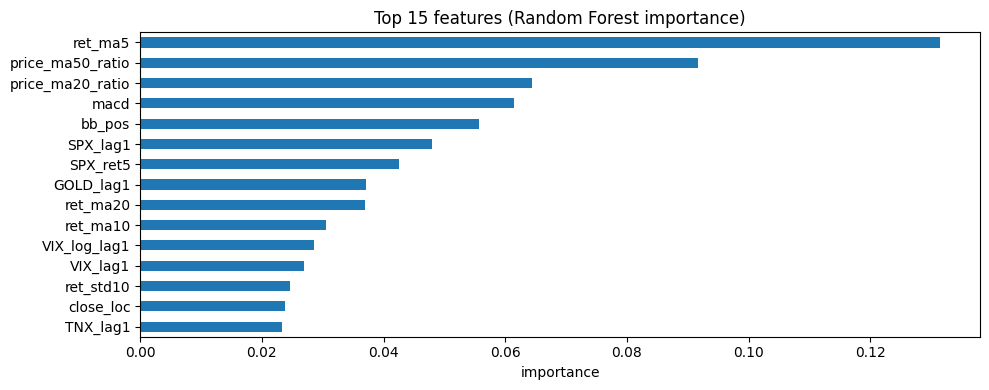


Top 5 features:
ret_ma5             0.131464
price_ma50_ratio    0.091740
price_ma20_ratio    0.064342
macd                0.061465
bb_pos              0.055652
dtype: float64


In [20]:
rf = models["RandomForest"]
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
top15 = fi.tail(15)

plt.figure(figsize=(10, 4))
top15.plot(kind="barh")
plt.title("Top 15 features (Random Forest importance)")
plt.xlabel("importance")
plt.tight_layout(); plt.show()

print("\nTop 5 features:")
print(top15.tail(5).iloc[::-1])

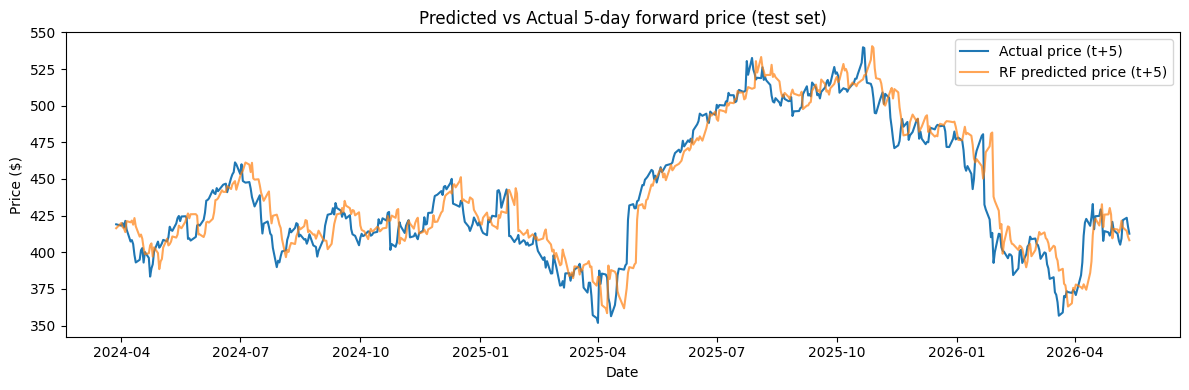

In [21]:
# realized 5-day-forward price from the full Close series
# (shifting within X_test would lose the last 5 rows)
test_dates = X_test.index
realized_price   = dataset["Close"].shift(-5).reindex(test_dates)
predicted_logret = models["RandomForest"].predict(X_test_scaled)
predicted_price  = feat_df.loc[test_dates, "Close"] * np.exp(predicted_logret)

plt.figure(figsize=(12, 4))
plt.plot(test_dates, realized_price,  label="Actual price (t+5)", linewidth=1.5)
plt.plot(test_dates, predicted_price, label="RF predicted price (t+5)", linewidth=1.5, alpha=0.7)
plt.title("Predicted vs Actual 5-day forward price (test set)")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.tight_layout(); plt.show()


# 8. Walk-forward Backtest

## run walk-forward

In [22]:
from src.forecast import walk_forward

# reuse tuned params from cell 32 so walk-forward matches the eval model
wf_rf_kwargs = dict(**best_params, random_state=SEED, n_jobs=-1)
wf = walk_forward(X, y, initial_train=1000, refit_every=21, horizon=5, rf_kwargs=wf_rf_kwargs)
print("Walk-forward predictions:", len(wf))
print(wf.head())


Walk-forward predictions: 2548
              y_true    y_pred  fit_id
date                                  
2016-03-22  0.017962  0.000831       0
2016-03-23  0.023078  0.001443       0
2016-03-24  0.024778  0.002150       0
2016-03-28  0.034692  0.004205       0
2016-03-29 -0.002746  0.002327       0


              Strategy_RF (primary)  Strategy_LR (baseline)  SPY B&H (benchmark)
Total return                 3.5541                  4.7275               3.1018
CAGR                         0.1616                  0.1882               0.1497
Sharpe                       0.6607                  0.8348               0.8146
Max DD                      -0.3219                 -0.2544              -0.2872

RF trades: 56  win rate: 57.3%  |  LR trades: 53  win rate: 58.7%  |  cost: 5 bps/leg


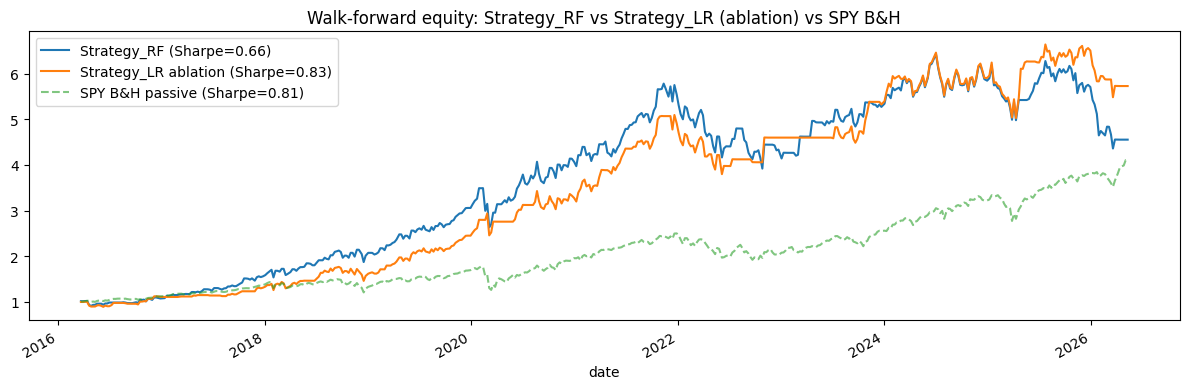

In [23]:
from sklearn.linear_model import LinearRegression
from src.forecast import walk_forward, backtest_strategy, perf_metrics
from src.data     import fetch_stock

# RF strategy (primary)
result = backtest_strategy(wf, horizon=5, cost_bps=5)

# LR baseline: same framework, simpler model
wf_lr  = walk_forward(X, y, initial_train=1000, refit_every=21, horizon=5,
                      model_factory=lambda: LinearRegression())
lr_res = backtest_strategy(wf_lr, horizon=5, cost_bps=5)

# SPY buy-and-hold: passive market benchmark
spy        = fetch_stock("SPY")
spy_fwd_lr = np.log(spy["Close"].shift(-5) / spy["Close"])
spy_ret    = spy_fwd_lr.reindex(result["bh_ret"].index).dropna()
spy_m      = perf_metrics(spy_ret, horizon=5)

def row(d): return [d["total_return"], d["cagr"], d["sharpe"], d["max_dd"]]
table = pd.DataFrame({
    "Strategy_RF (primary)":  row(result),
    "Strategy_LR (baseline)": row(lr_res),
    "SPY B&H (benchmark)":    row(spy_m),
}, index=["Total return", "CAGR", "Sharpe", "Max DD"])
print(table.round(4).to_string())
print(f"\nRF trades: {result['num_trades']}  win rate: {result['win_rate']*100:.1f}%"
      f"  |  LR trades: {lr_res['num_trades']}  win rate: {lr_res['win_rate']*100:.1f}%"
      f"  |  cost: {result['cost_bps']} bps/leg")

fig, ax = plt.subplots(figsize=(12, 4))
result["equity"].plot(ax=ax, label=f"Strategy_RF (Sharpe={result['sharpe']:.2f})")
lr_res["equity"].plot(ax=ax, label=f"Strategy_LR ablation (Sharpe={lr_res['sharpe']:.2f})")
spy_m["equity"].plot(ax=ax,  label=f"SPY B&H passive (Sharpe={spy_m['sharpe']:.2f})",
                     linestyle="--", alpha=0.6)
ax.set_title("Walk-forward equity: Strategy_RF vs Strategy_LR (ablation) vs SPY B&H")
ax.legend(); plt.tight_layout(); plt.show()
